In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from src.custom_kfold import CustomKFold
from src.sdee_statistics import calculate_nmae, calculate_mae
from src.train_dataset import get_X_y, train_model_cv
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import (
    SelectPercentile,
    f_regression,
    mutual_info_regression,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_regression
import json
from src.get_folds_results import get_fold_results
from src.plot_results import plot_feature_frequency_per_fold


In [2]:
feature_title_mapping = {
    "vel_todo": "To-do Velocity",
    "vel_done": "Done Velocity",
    "vel_removed": "Removed Velocity",
    "priority_freq_Major": "Frequency of Priority Major",
    "type_freq_Improvement": "Frequency of Type Improvement",
    "vel_starttime": "Velocity at Start Time",
    "vel_inprogress": "In-Progress Velocity",
    "type_freq_Bug": "Frequency of Type Bug",
    "type_freq_Story": "Frequency of Type Story",
    "priority_freq_Critical": "Frequency of Priority Critical",
        "priority_freq_Major - P3": "Frequency of Priority Major-P3",
    "vel_added": "Added Velocity",
    "gunning_fog_freq_hard": "Frequency of Gunning Fog Hard",
    "no_issuetodo": "No. of To-Do Issues",
    "no_issue_added": "No. of Issues Added",
    "no_issue_removed": "No. of Issues Removed",
    "no_teammember": "No. of Team Members",
    "gunning_fog_freq_easy": "Frequency of Gunning Fog Easy",
    "type_freq_Task": "Frequency of Type Task",
    "type_freq_Sub-task": "Frequency of Type Subtask",
    "type_freq_Feature Request": "Frequency of Type Feature Request",
    "no_issue_starttime": "No. of Issues at Start Time",
    "type_freq_Technical task": "Frequency of Type Technical Task",
    "no_issueinprogress": "No. of Issues In Progress",
    "no_fixversion_var": "No. of Fix Version Changes",
    "no_comment_std": "Standard Deviation of No. of Comments",
    "no_comment_min": "Min No. of Comments",
    "no_comment_max": "Max No. of Comments",
    "no_comment_mean": "Mean No. of Comments",
    "priority_freq_Minor": "Frequency of Priority Minor",
    "no_issuedone": "No. of Done Issues",
    "no_fixversion_mean": "Mean No. of Fix Version",
        "no_des_change_mean": "Mean No. of Description Changes"

}

datasets = [
    "apache_iteration_30_features",
    "jboss_iteration_30_features",
    "jira_iteration_30_features",
    "mongodb_iteration_30_features",
    "spring_iteration_30_features",
]
dataset_mappings = {
    "apache_iteration_30_features": "Apache",
    "jboss_iteration_30_features": "JBoss",
    "jira_iteration_30_features": "Jira",
    "mongodb_iteration_30_features": "MongoDB",
    "spring_iteration_30_features": "Spring"
}

In [34]:
#dataset = "apache_iteration_30_features"
#dataset_iteration_30 = pd.read_csv(f"datasets/{dataset}.csv")
#
## Create a condition-checking column
#dataset_iteration_30['valid_issues'] = (
#    dataset_iteration_30["no_issues"] == 
#    dataset_iteration_30["no_issue_starttime"] + dataset_iteration_30["no_issue_added"] - dataset_iteration_30["no_issue_removed"]
#)
#columns_of_interest = [
#    'valid_issues',
#    'no_issues',
#    'no_issue_starttime',
#    'no_issue_added',
#    'no_issue_removed'
#]
## Reorder columns to place the checking column at the front
#columns = columns_of_interest + [col for col in dataset_iteration_30.columns if col != 'valid_issues']
## Create a new DataFrame with reordered columns
#result_df = dataset_iteration_30[columns]
#
## Store the DataFrame to a CSV file
#result_df.to_csv("datasets/check.csv", index=False)



In [42]:
# load dataset heads:
datasets = [
    "apache_iteration_30_features",
    "jboss_iteration_30_features",
    "jira_iteration_30_features",
    "mongodb_iteration_30_features",
    "spring_iteration_30_features",
]
for dataset in datasets:
    print("================================")
    print(f"Dataset {dataset}")
    dataset_iteration_30 = pd.read_csv(
        f"datasets/{dataset}.csv")
    dataset_iteration_30.rename(columns=feature_title_mapping, inplace=True)
    dataset_iteration_30.head(1)
    # setup model:
    X, y = get_X_y(dataset_iteration_30)

    num_features_original = X.shape[1]
    print(f"Number of features in original dataset: {num_features_original}")


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0)

    custom_kfold = CustomKFold(n_splits=10, shuffle=False)
    nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)
    mae_scorer = make_scorer(calculate_mae, greater_is_better=False)

    # train model
    random_forest = RandomForestRegressor(
        n_estimators=500, max_depth=7, random_state=42)

    def custom_scorer(X, y):
        random_forest.fit(X, y)
        return random_forest.feature_importances_

    sfs_pipeline = Pipeline(
        [
            (
                "feature_selection",
                SelectPercentile(percentile=20,  score_func=custom_scorer),
            ),
            ("regressor", random_forest),
        ]
    )
    sfs_pipeline.fit(X_train, y_train)

    num_features_selected = sfs_pipeline.named_steps["feature_selection"].get_support().sum()
    print(f"Number of features selected by SelectPercentile: {num_features_selected}")


    #######################
    import shap
    #X_train, X_test, y_train, y_test = train_test_split(
    #    X, y, test_size=0.2, random_state=0)
    # rf = random_forest.fit(X_train, y_train)

    explainer = shap.TreeExplainer(
        sfs_pipeline.named_steps["regressor"])
    shap_values = explainer(X_train)

    # Calculate the mean absolute SHAP values for each feature
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'mean_abs_shap': mean_abs_shap
    })

    # Sort the features by importance
    feature_importance = feature_importance.sort_values(
        by='mean_abs_shap', ascending=False).reset_index(drop=True)

    # Display the ranking of features as text
    for idx, row in feature_importance.head(10).iterrows():
       print(row.feature)

    shap.plots.beeswarm(shap_values, max_display=6, show=False)

    # plt.title(f'SHAP beeswarm plot for {dataset_mappings[dataset]}')
    for idx, feature in enumerate(X_train.columns):
        if feature in feature_title_mapping:
            plt.xticks(ticks=range(len(X_train.columns)), labels=[
                       feature_title_mapping.get(f, f) for f in X_train.columns], rotation=45)

    plt.savefig(f'outputs/shap/{dataset}_beeswarm.png', bbox_inches='tight')
    plt.close()

Dataset apache_iteration_30_features
Number of features in original dataset: 96
Number of features selected by SelectPercentile: 19
Velocity at Start Time
Removed Velocity
To-do Velocity
Frequency of Major Priority
Done Velocity
Min No. of Comments
No. of To-Do Issues
No. of Issues In Progress
No. of Done Issues
No. of Issues at Start Time
Dataset jboss_iteration_30_features
Number of features in original dataset: 95
Number of features selected by SelectPercentile: 19
Added Velocity
No. of Issues at Start Time
Velocity at Start Time
Frequency of type Feature Request
Frequency of Major Priority
Frequency of type Subtask
Removed Velocity
No. of Issues Removed
No. of To-Do Issues
No. of Issues Added
Dataset jira_iteration_30_features
Number of features in original dataset: 103
Number of features selected by SelectPercentile: 21
Frequency of type Subtask
Removed Velocity
Max No. of Comments
No. of Team Members
No. of Issues at Start Time
No. of To-Do Issues
Velocity at Start Time
Mean No. 

In [5]:
import shap

for dataset in datasets:
    print("================================")
    print(f"Dataset {dataset}")
    dataset_iteration_30 = pd.read_csv(f"datasets/{dataset}.csv")
    dataset_iteration_30.rename(columns=feature_title_mapping, inplace=True)
    dataset_iteration_30.head(1)

    # Setup model:
    X, y = get_X_y(dataset_iteration_30)
    num_features_original = X.shape[1]
    print(f"Number of features in original dataset: {num_features_original}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    custom_kfold = CustomKFold(n_splits=10, shuffle=False)
    nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)
    mae_scorer = make_scorer(calculate_mae, greater_is_better=False)

    # Define model
    random_forest = RandomForestRegressor(
        n_estimators=500, max_depth=7, random_state=42
    )

    def custom_scorer(X, y):
        random_forest.fit(X, y)
        return random_forest.feature_importances_

    # Create pipeline with feature selection
    sfs_pipeline = Pipeline(
        [
            (
                "feature_selection",
                SelectPercentile(percentile=20, score_func=custom_scorer),
            ),
            ("regressor", random_forest),
        ]
    )

    X_reduced = sfs_pipeline.named_steps["feature_selection"].fit_transform(X_train, y_train)

    selected_features_mask = sfs_pipeline.named_steps["feature_selection"].get_support()
    selected_feature_names = X_train.columns[selected_features_mask]
    X_reduced = pd.DataFrame(X_reduced, columns=selected_feature_names)
    
    num_features_selected = selected_features_mask.sum()
    print(f"Number of features selected by SelectPercentile: {num_features_selected}")

    sfs_pipeline.named_steps["regressor"].fit(X_reduced, y_train)


    # Generate SHAP values for the selected features
    explainer = shap.TreeExplainer(sfs_pipeline.named_steps["regressor"])
    shap_values = explainer(X_reduced)

    # Step 5: Calculate mean absolute SHAP values for each selected feature
    selected_features_mask = sfs_pipeline.named_steps["feature_selection"].get_support()
    selected_feature_names = X_train.columns[selected_features_mask]
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'feature': selected_feature_names,
        'mean_abs_shap': mean_abs_shap
    })

    # Sort the features by importance
    feature_importance = feature_importance.sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

    # Display the ranking of the top features as text
    for idx, row in feature_importance.head(10).iterrows():
        print(row.feature)

    mapped_feature_names = [feature_title_mapping.get(f, f) for f in selected_feature_names]
    
    # Generate SHAP beeswarm plot using only the selected features
    #shap.summary_plot(shap_values, feature_names=mapped_feature_names, plot_type="bar", max_display=6)


    shap.plots.beeswarm(shap_values, max_display=6, show=False)

    # Adjust feature labels for the plot
    for idx, feature in enumerate(X_train.columns):
        if feature in feature_title_mapping:
            plt.xticks(ticks=range(len(X_train.columns)), labels=[
                       feature_title_mapping.get(f, f) for f in X_train.columns], rotation=45)

    # Save the plot
    plt.savefig(f'outputs/shap/2_{dataset}_beeswarm.png', bbox_inches='tight')
    plt.close()


Dataset apache_iteration_30_features
Number of features in original dataset: 96
Number of features selected by SelectPercentile: 19
To-do Velocity
Velocity at Start Time
Frequency of Improvement Type
Frequency of Hard Gunning Fog
Frequency of Major Priority
In-Progress Velocity
Frequency of Story Type
type_freq_Documentation
No. of Team Members
No. of Issues at Start Time
Dataset jboss_iteration_30_features
Number of features in original dataset: 95
Number of features selected by SelectPercentile: 19
To-do Velocity
No. of Issues at Start Time
Velocity at Start Time
In-Progress Velocity
No. of Issues In Progress
No. of To-Do Issues
No. of Team Members
no_des_change_mean
no_fixversion_change_mean
Frequency of Major Priority
Dataset jira_iteration_30_features
Number of features in original dataset: 103
Number of features selected by SelectPercentile: 21
To-do Velocity
Frequency of Improvement Type
Frequency of Major Priority
Velocity at Start Time
In-Progress Velocity
Frequency of Bug Typ

## SHAP

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rank 1: vel_added - Mean SHAP Value: 1.2537147969526252
Rank 2: type_freq_Bug - Mean SHAP Value: 0.9679234110744235
Rank 3: vel_starttime - Mean SHAP Value: 0.7801136700213108
Rank 4: no_issue_starttime - Mean SHAP Value: 0.7790003221607191
Rank 5: vel_todo - Mean SHAP Value: 0.6299048359832045
Rank 6: type_freq_Feature Request - Mean SHAP Value: 0.5623250396054952
Rank 7: vel_removed - Mean SHAP Value: 0.5011371922413584
Rank 8: no_issues - Mean SHAP Value: 0.4026302348498075
Rank 9: no_issue_removed - Mean SHAP Value: 0.2889463751234391
Rank 10: type_freq_Sub-task - Mean SHAP Value: 0.24123226372470483
Rank 11: vel_done - Mean SHAP Value: 0.20571877441671912
Rank 12: no_issuetodo - Mean SHAP Value: 0.147906471036903
Rank 13: no_teammember - Mean SHAP Value: 0.1396957683917363
Rank 14: vel_inprogress - Mean SHAP Value: 0.10639877681859582
Rank 15: no_issue_added - Mean SHAP Value: 0.0731197975467815
Rank 16: priority_freq_Major - Mean SHAP Value: 0.02336270509366796
Rank 17: no_admin 

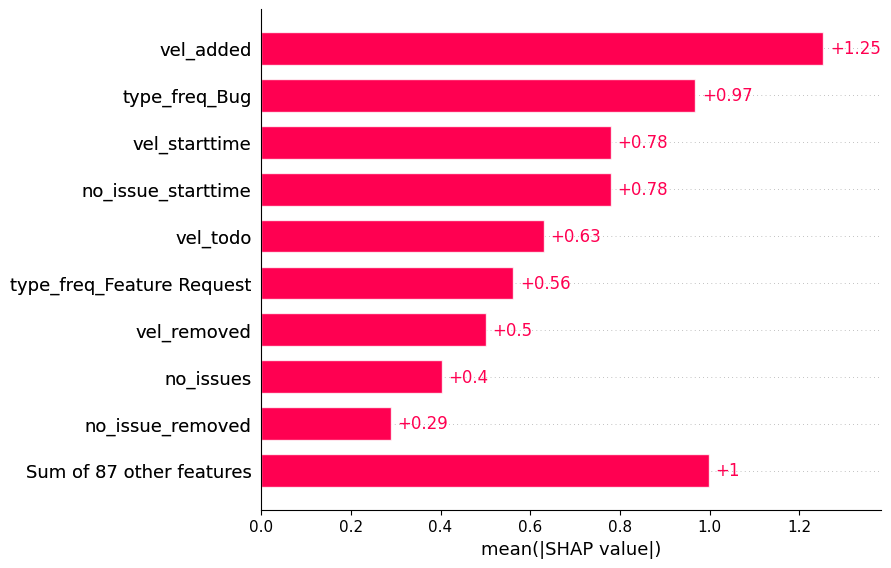

In [31]:
shap.plots.bar(shap_values, max_display=10)

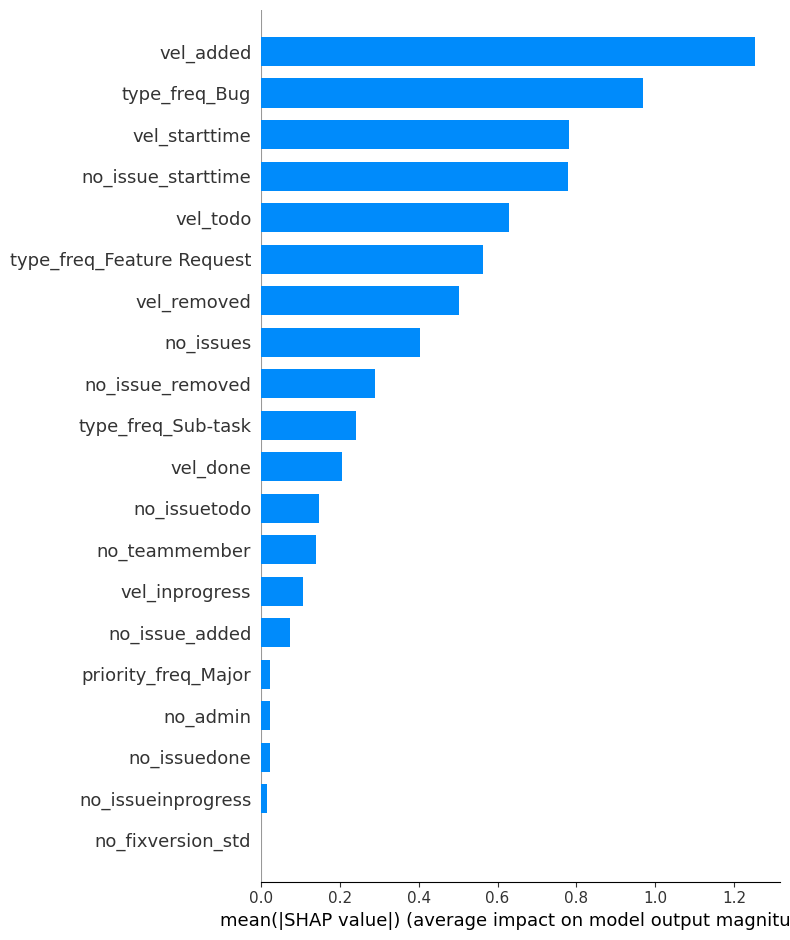

: 

In [48]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
})

# Sort the features by importance
feature_importance = feature_importance.sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# Display the feature importance data as text
print(feature_importance)

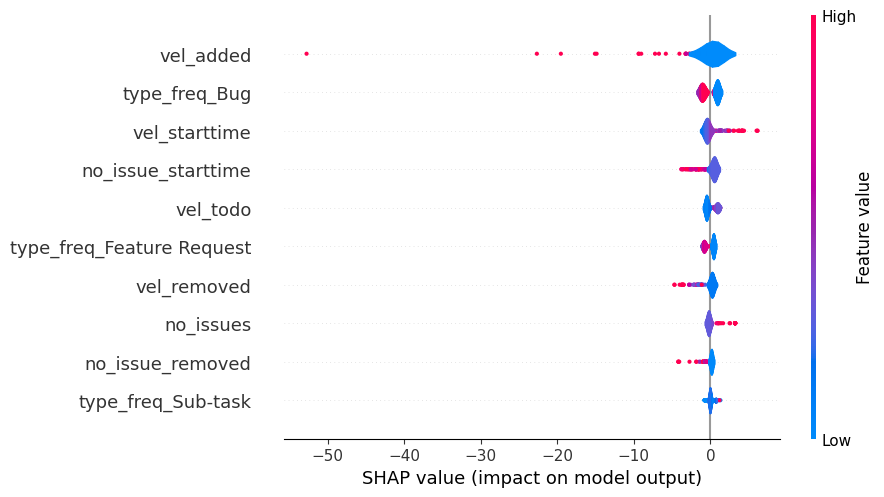

In [33]:
shap.plots.violin(shap_values, max_display=10)

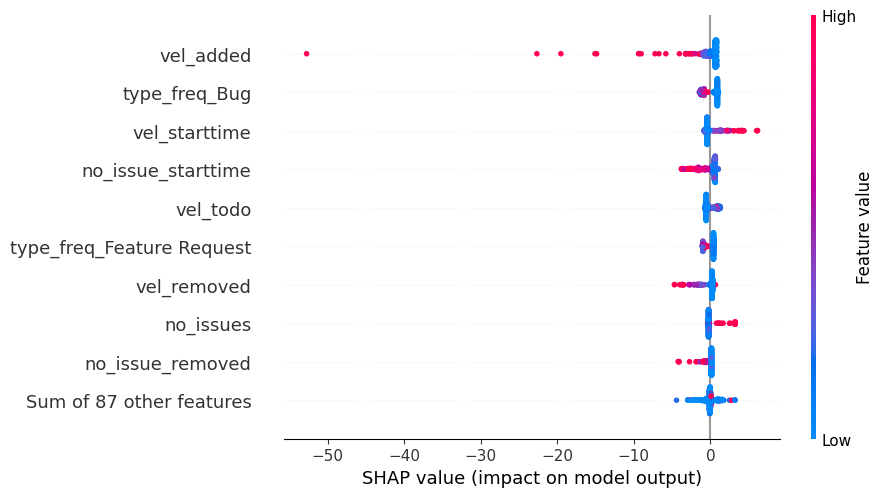

In [34]:
shap.plots.beeswarm(shap_values, max_display=10)

In [35]:
shap.initjs()
plot = shap.plots.force(shap_values[0])
shap.save_html("shap_force_plot.html", plot)

In [36]:
#shap.decision_plot(explainer.expected_value, shap_values, X)

In [37]:
#hap.dependence_plot('vel_todo', shap_values, X)

IndexError: index 297 is out of bounds for axis 0 with size 297

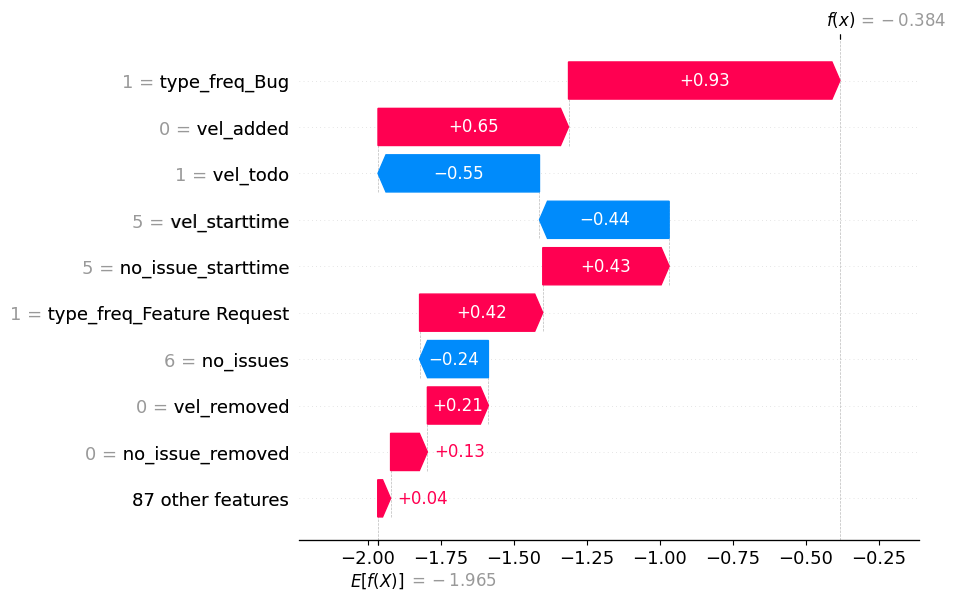

In [40]:
shap.plots.waterfall(shap_values[0])

## LIME

In [41]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.values.tolist(),
                                                  class_names=['vel_diff'], 
                                                  verbose=True, mode='regression')

In [44]:
# Choose the 5th instance and use it to predict the results
j = 5
exp = explainer.explain_instance(X_test.values[3], sfs_pipeline.predict, num_features=10)
exp.show_in_notebook(show_table=True)
exp.save_to_file(file_path="outputs/lime/ins5.html")

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SelectPercentile was fitted with feature names
  warnings.warn(


Intercept -13.654842766436289
Prediction_local [-0.14849896]
Right: -0.2565451937954099


In [18]:
# Choose the 5th instance and use it to predict the results
j = 10
exp = explainer.explain_instance(X_test.values[j], sfs_pipeline.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SelectPercentile was fitted with feature names
  warnings.warn(


Intercept -2.438438025561279
Prediction_local [-0.01457125]
Right: 0.25272795722885527


In [18]:
# Choose the 5th instance and use it to predict the results
j = 15
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 3.4774806819261377
Prediction_local [3.90807265]
Right: 8.988787793500784


In [19]:
# Choose the 5th instance and use it to predict the results
j = 20
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 4.290481100154261
Prediction_local [-1.90994963]
Right: -2.2170588996494676
